In [ ]:
!pip install --upgrade datasets>=2.18.0 huggingface-hub>=0.21.2 fsspec>=2023.12.0 transformers

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is incompatible.


In [ ]:
!pip install datasets transformers tokenizers tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from datasets import load_dataset, concatenate_datasets, ClassLabel
import re

def process_sarcasm_example(example):
    match = re.match(r'^(\d+)_', example['id_col'])
    star = int(match.group(1)) if match else 3
    if star not in range(1, 6):
        star = 3
    return {
        'text': example['text_col'],
        'label': star - 1
    }

custom_ds_raw = load_dataset(
    'csv',
    data_files="/content/drive/MyDrive/Sentimental Analysis data/sarcasm_lines.txt",
    delimiter='\t',
    column_names=['id_col', 'text_col'],
    header=None
)

custom_train = custom_ds_raw['train'].map(
    process_sarcasm_example,
    remove_columns=['id_col', 'text_col']
)

# Cast to match yelp's exact ClassLabel schema
yelp_class_label = ClassLabel(names=['1 star', '2 star', '3 stars', '4 stars', '5 stars'])
custom_train = custom_train.cast_column('label', yelp_class_label)

print(custom_train.features)  # should show ClassLabel(names=[...])

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/437 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/437 [00:00<?, ? examples/s]

{'text': Value('string'), 'label': ClassLabel(names=['1 star', '2 star', '3 stars', '4 stars', '5 stars'])}


In [ ]:
## Transformer Text Classifier with Hugging Face BPE Subtokenizer
# Import required libraries

# Cell 1: Install required packages if not already installed

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pickle
import math
from datasets import concatenate_datasets
from datasets import load_dataset
from tokenizers import ByteLevelBPETokenizer
from tokenizers.processors import BertProcessing
import os
import gc
import numpy as np
from tqdm.notebook import tqdm
import time

# Cell 2: Initialize and train BPE tokenizer
VOCAB_SIZE = 30000
MIN_FREQUENCY = 2
SPECIAL_TOKENS = ["[PAD]", "[UNK]", "[CLS]", "[SEP]"]

# Train a Byte-Level BPE tokenizer on the training texts
def train_bpe_tokenizer(text_iterable, vocab_size=VOCAB_SIZE, min_frequency=MIN_FREQUENCY):
    # Use a small sample for training the tokenizer to save memory
    if isinstance(text_iterable, list):
        sample_size = min(30000, len(text_iterable))
        import random
        random.seed(42)
        sample_texts = random.sample(text_iterable, sample_size)
    else:
        # For dataset iterables
        sample_texts = []
        for i, text in enumerate(text_iterable):
            if i >= 30000:
                break
            sample_texts.append(text)

    tokenizer = ByteLevelBPETokenizer(
        lowercase=True,
        add_prefix_space=True
    )
    tokenizer.train_from_iterator(
        sample_texts,
        vocab_size=vocab_size,
        min_frequency=min_frequency,
        special_tokens=SPECIAL_TOKENS
    )
    tokenizer._tokenizer.post_processor = BertProcessing(
        ("[SEP]", tokenizer.token_to_id("[SEP]")),
        ("[CLS]", tokenizer.token_to_id("[CLS]"))
    )
    tokenizer.enable_truncation(max_length=256)
    tokenizer.enable_padding(
        length=256,
        pad_id=tokenizer.token_to_id("[PAD]"),
        pad_token="[PAD]"
    )
    return tokenizer

# Cell 4: Memory-efficient dataset class
class TokenizedDataset(Dataset):
    def __init__(self, dataset, tokenizer, max_len=256, text_field='text', label_field='label'):
        self.dataset = dataset
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.text_field = text_field
        self.label_field = label_field

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        text = item[self.text_field] or ""  # ← add this guard
        label = item[self.label_field]
        encoding = self.tokenizer.encode(text)
        input_ids = torch.tensor(encoding.ids, dtype=torch.long)
        return input_ids, torch.tensor(label, dtype=torch.long)

# Cell 5: Hyperparameters and data loading
D_MODEL = 128  # 512
NUM_HEADS = 4  # 8
D_FF = 512     # 2048
NUM_LAYERS = 2 # 4
MAX_LEN = 256
DROPOUT = 0.1
BATCH_SIZE = 64
LR = 3e-4
EPOCHS = 30
DATASET_NAME = 'yelp_review_full'

# Cell 6: Load and process data
def load_and_process_data(dataset_name=DATASET_NAME, extra_train=None):
    print(f"Loading dataset '{dataset_name}'...")
    ds = load_dataset(dataset_name)

    if extra_train is not None:
        # Cast extra_train to match yelp's features before concatenating
        extra_train = extra_train.cast(ds['train'].features)
        train = concatenate_datasets([ds['train'], extra_train])
    else:
        train = ds['train']

    test = ds['test']
    unique_labels = set(train['label'])
    num_classes = len(unique_labels)
    print(f"Detected {num_classes} classes in dataset '{dataset_name}'")

    print("Training BPE tokenizer...")
    tokenizer = train_bpe_tokenizer(train['text'], vocab_size=VOCAB_SIZE)
    print(f"Tokenizer vocabulary size: {tokenizer.get_vocab_size()}")

    # Create memory-efficient datasets
    print("Creating memory-efficient datasets...")
    train_dataset = TokenizedDataset(train, tokenizer)
    test_dataset = TokenizedDataset(test, tokenizer)

    print(f"Training samples: {len(train_dataset)}")
    print(f"Test samples: {len(test_dataset)}")

    return tokenizer, train_dataset, test_dataset, num_classes

tokenizer, train_dataset, test_dataset, num_classes = load_and_process_data(
    extra_train=custom_train
)

# Initialize model, loss, and optimizer
def init_model(vocab_size, num_classes):
    model = TransformerClassifier(
        vocab_size=vocab_size,
        num_classes=num_classes,
        d_model=D_MODEL,
        num_heads=NUM_HEADS,
        d_ff=D_FF,
        num_layers=NUM_LAYERS,
        max_len=MAX_LEN,
        dropout=DROPOUT
    )

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR)

    return model, criterion, optimizer, device



Loading dataset 'yelp_review_full'...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

yelp_review_full/train-00000-of-00001.pa(…):   0%|          | 0.00/299M [00:00<?, ?B/s]

yelp_review_full/test-00000-of-00001.par(…):   0%|          | 0.00/23.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/650000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/437 [00:00<?, ? examples/s]

Detected 5 classes in dataset 'yelp_review_full'
Training BPE tokenizer...
Tokenizer vocabulary size: 30000
Creating memory-efficient datasets...
Training samples: 650437
Test samples: 50000


In [ ]:
## Transformer Text Classifier with Hugging Face BPE Subtokenizer
# Import required libraries

# Cell 1: Install required packages if not already installed

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pickle
import math
from datasets import concatenate_datasets
from datasets import load_dataset
from tokenizers import ByteLevelBPETokenizer
from tokenizers.processors import BertProcessing
import os
import gc
import numpy as np
from tqdm.notebook import tqdm
import time

# Cell 2: Initialize and train BPE tokenizer

# Cell 5: Hyperparameters and data loading
D_MODEL = 128  # 512
NUM_HEADS = 4  # 8
D_FF = 512     # 2048
NUM_LAYERS = 2 # 4
MAX_LEN = 256
DROPOUT = 0.1
BATCH_SIZE = 64
LR = 3e-4
EPOCHS = 30
DATASET_NAME = 'yelp_review_full'


# Cell 3: Transformer model architecture (unchanged)
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class TransformerInputLayer(nn.Module):
    def __init__(self, vocab_size, d_model, max_len=256, dropout=0.1):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_len)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids):
        x = self.token_embedding(input_ids)
        x = self.positional_encoding(x)
        return self.dropout(x)

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads):     # apple [128] ---> Wq , Wk , Wv  --> Q,K,V  = Q.K = attention(0.78) --> [128] -->king
        super().__init__()
        assert d_model % num_heads == 0
        self.d_k = d_model // num_heads
        self.num_heads = num_heads
        self.q_linear = nn.Linear(d_model, d_model)
        self.k_linear = nn.Linear(d_model, d_model)
        self.v_linear = nn.Linear(d_model, d_model)
        self.out_linear = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(0.1)

    def forward(self, x, mask=None):
        B, T, D = x.size()
        Q = self.q_linear(x).view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        K = self.k_linear(x).view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        V = self.v_linear(x).view(B, T, self.num_heads, self.d_k).transpose(1, 2)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        attn = torch.softmax(scores, dim=-1)
        out = torch.matmul(self.dropout(attn), V)
        out = out.transpose(1, 2).contiguous().view(B, T, D)
        return self.out_linear(out)

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.relu1 = nn.ReLU()
        self.linear2 = nn.Linear(d_ff, d_ff//2)
        self.relu2 = nn.ReLU()
        self.linear3 = nn.Linear(d_ff//2, d_model)
        self.dropout = nn.Dropout(0.1)

    def forward(self, x):
        return self.linear3(self.dropout(self.relu2(self.linear2(self.relu1(self.linear1(x))))))  #--2 layer
class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff):
        super().__init__()
        self.attn = MultiHeadSelfAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = FeedForward(d_model, d_ff)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(0.1)

    def forward(self, x, mask=None):
        attn_out = self.attn(x, mask)
        x = self.norm1(x + self.dropout(attn_out))
        ff_out = self.ff(x)
        return self.norm2(x + self.dropout(ff_out))

class TransformerEncoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_layers, max_len, dropout):
        super().__init__()
        self.input_layer = TransformerInputLayer(vocab_size, d_model, max_len, dropout)
        self.layers = nn.ModuleList([
            TransformerEncoderBlock(d_model, num_heads, d_ff)
            for _ in range(num_layers)
        ])

    def forward(self, input_ids, mask=None):
        x = self.input_layer(input_ids)
        for layer in self.layers:
            x = layer(x, mask)
        return x

class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, num_classes, d_model, num_heads, d_ff, num_layers, max_len, dropout):
        super().__init__()
        self.encoder = TransformerEncoder(vocab_size, d_model, num_heads, d_ff, num_layers, max_len, dropout)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, input_ids, mask=None):
        x = self.encoder(input_ids, mask)
        cls_out = x[:, 0, :]
        return self.classifier(cls_out)


def init_model(vocab_size, num_classes):
    model = TransformerClassifier(
        vocab_size=vocab_size,
        num_classes=num_classes,
        d_model=D_MODEL,
        num_heads=NUM_HEADS,
        d_ff=D_FF,
        num_layers=NUM_LAYERS,
        max_len=MAX_LEN,
        dropout=DROPOUT
    )

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR)

    return model, criterion, optimizer, device

In [ ]:
## Transformer Text Classifier with Hugging Face BPE Subtokenizer
# Import required libraries

# Cell 1: Install required packages if not already installed

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pickle
import math
from datasets import concatenate_datasets
from datasets import load_dataset
from tokenizers import ByteLevelBPETokenizer
from tokenizers.processors import BertProcessing
import os
import gc
import numpy as np
from tqdm.notebook import tqdm
import time

# Cell 2: Initialize and train BPE tokenizer

# Cell 5: Hyperparameters and data loading
D_MODEL = 128  # 512
NUM_HEADS = 4  # 8
D_FF = 512     # 2048
NUM_LAYERS = 2 # 4
MAX_LEN = 256
DROPOUT = 0.1
BATCH_SIZE = 64
LR = 3e-4
EPOCHS = 30
DATASET_NAME = 'yelp_review_full'


# Cell 7: Checkpoint functions
def setup_checkpointing():
    if os.path.exists('/content/drive/MyDrive/model_checkpoints'):
        CHECKPOINT_DIR = '/content/drive/MyDrive/model_checkpoints'
    else:
        CHECKPOINT_DIR = './model_checkpoints'

    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, 'transformer_classifier_checkpoint_best_best.pth')
    return CHECKPOINT_PATH

def save_checkpoint(model, optimizer, epoch, loss, path):
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }, path)
    print(f"Checkpoint saved at epoch {epoch+1}")

def load_checkpoint(model, optimizer, path, device):
    if os.path.exists(path):
        checkpoint = torch.load(path, map_location=device)
        model.load_state_dict(checkpoint)
    return 0

# Cell 8: Training and evaluation functions
def train_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(train_loader, desc="Training")
    for inputs, labels in progress_bar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Calculate accuracy
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # Update progress bar
        progress_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{correct/total:.4f}"
        })

    avg_loss = total_loss / len(train_loader)
    accuracy = correct / total
    return avg_loss, accuracy

def evaluate(model, test_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Evaluating"):
            inputs, labels = inputs.to(device), labels.to(device)
            logits = model(inputs)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(test_loader)
    accuracy = correct / total
    return avg_loss, accuracy

# Cell 9: Main training loop
def train_model(model, train_dataset, test_dataset, criterion, optimizer, device, checkpoint_path, epochs=EPOCHS):
    # Set up data loaders with appropriate batch size and num_workers
    NWORKERS = 12
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NWORKERS,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NWORKERS,
        pin_memory=True
    )

    # Try to load checkpoint
    start_epoch = load_checkpoint(model, optimizer, checkpoint_path, device)

    best_accuracy = 0.0

    for epoch in range(start_epoch, epochs):
        start_time = time.time()

        # Train for one epoch
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)

        # Evaluate
        val_loss, val_acc = evaluate(model, test_loader, criterion, device)

        # Report metrics
        epoch_time = time.time() - start_time
        print(f"Epoch {epoch+1}/{epochs} | Time: {epoch_time:.2f}s")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        # Save checkpoint
        save_checkpoint(model, optimizer, epoch, val_loss, checkpoint_path)

        # Save best model
        if val_acc > best_accuracy:
            best_accuracy = val_acc
            best_model_path = checkpoint_path
            torch.save(model.state_dict(), best_model_path)
            print(f"New best model saved with accuracy: {best_accuracy:.4f}")

        # Force garbage collection to free memory
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return model

# Cell 10: Example inference
def predict_sentiment(text, model, tokenizer, device, num_classes):
    enc = tokenizer.encode(text)
    input_ids = torch.tensor([enc.ids]).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(input_ids)
        probs = torch.softmax(logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()
        # Map score to sentiment (for Yelp dataset)
        if num_classes == 5:  # Yelp dataset
            sentiment_map = {
                0: "Very Negative (1 star)",
                1: "Negative (2 stars)",
                2: "Neutral (3 stars)",
                3: "Positive (4 stars)",
                4: "Very Positive (5 stars)"
            }
            return sentiment_map.get(pred, f"Class {pred}"), probs[0][pred].item()
        else:
            return pred, probs[0][pred].item()

# Cell 11: Save model artifacts
def save_artifacts(model, tokenizer, device):
    # Save model state
    torch.save(model.state_dict(), "transformer_classifier.pth")

    # Save tokenizer
    with open("tokenizer.json", "w") as f:
        f.write(tokenizer.to_str())

    print("Model and tokenizer saved successfully.")

# Cell 12: Main execution
def main():
    # Load and process data
    tokenizer, train_dataset, test_dataset, num_classes = load_and_process_data()

    # Initialize model and related components
    model, criterion, optimizer, device = init_model(tokenizer.get_vocab_size(), num_classes)

    # Setup checkpointing
    checkpoint_path = setup_checkpointing()

    # Train model
    model = train_model(model, train_dataset, test_dataset, criterion, optimizer, device, checkpoint_path)

    # Save artifacts
    save_artifacts(model, tokenizer, device)

    # Example inference
    sample_text = "The food was delicious and the service was excellent!"
    sentiment, confidence = predict_sentiment(sample_text, model, tokenizer, device, num_classes)
    print(f"Sample text: '{sample_text}'")
    print(f"Predicted sentiment: {sentiment} (confidence: {confidence:.4f})")

main()

Loading dataset 'yelp_review_full'...
Detected 5 classes in dataset 'yelp_review_full'
Training BPE tokenizer...
Tokenizer vocabulary size: 30000
Creating memory-efficient datasets...
Training samples: 650000
Test samples: 50000
Using device: cuda


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Training:   0%|          | 0/10157 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 12 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Evaluating:   0%|          | 0/782 [00:00<?, ?it/s]

...

Training:   0%|          | 0/10157 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 14/30 | Time: 554.43s
Train Loss: 0.7959 | Train Acc: 0.6558
Val Loss: 0.8624 | Val Acc: 0.6272
Checkpoint saved at epoch 14
New best model saved with accuracy: 0.6272


Training:   0%|          | 0/10157 [00:00<?, ?it/s]

KeyboardInterrupt: 

Re-loading tokenizer and test dataset...
Using device: cuda
Loading model weights from /content/drive/MyDrive/model_checkpoints/transformer_classifier_checkpoint_best_best.pth...
Model weights loaded successfully.
Generating predictions and true labels on the test set...
Calculating Confusion Matrix...


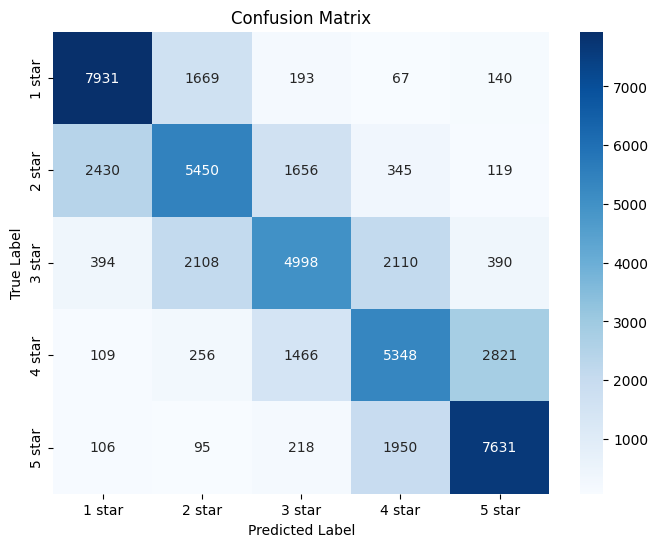


Classification Report:
              precision    recall  f1-score   support

      1 star       0.72      0.79      0.76     10000
      2 star       0.57      0.55      0.56     10000
     3 stars       0.59      0.50      0.54     10000
     4 stars       0.54      0.53      0.54     10000
     5 stars       0.69      0.76      0.72     10000

    accuracy                           0.63     50000
   macro avg       0.62      0.63      0.62     50000
weighted avg       0.62      0.63      0.62     50000

Model evaluation complete.


In [ ]:
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

print("Re-loading tokenizer and test dataset...")

if os.path.exists('/content/drive/MyDrive/model_checkpoints'):
    CHECKPOINT_DIR = '/content/drive/MyDrive/model_checkpoints'
else:
    CHECKPOINT_DIR = './model_checkpoints'

# Ensure the directory exists, although it should already from training
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
MODEL_PATH = os.path.join(CHECKPOINT_DIR, 'transformer_classifier_checkpoint_best_best.pth')

# Re-initialize the model architecture
# Need vocab_size which can be obtained from the tokenizer
vocab_size = tokenizer.get_vocab_size()

# Initialize model, criterion, optimizer, device as done before
model_eval, criterion_eval, optimizer_eval, device_eval = init_model(vocab_size, num_classes)

# Load the saved best model weights
if os.path.exists(MODEL_PATH):
    print(f"Loading model weights from {MODEL_PATH}...")
    # Only load model state dict, not the full checkpoint object from `save_checkpoint`
    model_eval.load_state_dict(torch.load(MODEL_PATH, map_location=device_eval))
    model_eval.eval() # Set model to evaluation mode
    print("Model weights loaded successfully.")
else:
    print(f"Error: Model weights not found at {MODEL_PATH}. Please ensure the training cell ran successfully and saved the model.")


def get_predictions_and_labels(model, dataset, device, batch_size):
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            logits = model(inputs)
            predictions = torch.argmax(logits, dim=1)
            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_preds), np.array(all_labels)

print("Generating predictions and true labels on the test set...")
# Ensure `device_eval` and `BATCH_SIZE` are available from kernel or re-defined.
# The kernel state shows `BATCH_SIZE` is 64.
predictions, true_labels = get_predictions_and_labels(model_eval, test_dataset, device_eval, BATCH_SIZE)

# Calculate and display Confusion Matrix
print("Calculating Confusion Matrix...")
cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'{i+1} star' for i in range(num_classes)],
            yticklabels=[f'{i+1} star' for i in range(num_classes)])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Calculate and display Classification Report
print("\nClassification Report:")
# Get target names from ClassLabel if available or create generic ones
# Fix TypeError: argument of type 'ClassLabel' is not iterable
if hasattr(test_dataset.dataset.features['label'], 'names'):
    target_names = test_dataset.dataset.features['label'].names
else:
    target_names = [f'{i+1} star' for i in range(num_classes)]

print(classification_report(true_labels, predictions, target_names=target_names))

print("Model evaluation complete.")
